In [1]:
from datetime import time
from os import times
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as patches
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import math
from cartopy.mpl.ticker import LongitudeFormatter,LatitudeFormatter

#math的相关函数，import后可以直接使用
from math import radians
from math import sin
from math import cos
from math import asin
from math import sqrt

# np.set_printoptions(threshold=np.inf)#显示所有的数组
from geopy.distance import great_circle
from geopy.distance import geodesic
import matplotlib
# matplotlib.rcParams['font.family'] = 'Times New Roman'
import seaborn as sns
from scipy import stats

# from jupyterthemes import jtplot
# jtplot.style()


In [2]:
# 计算弯曲度的函数
def calculate_sinuosity(latitudes, longitudes):
    # 计算路径的实际长度
    path_length = 0
    for i in range(1, len(latitudes)):
        point1 = (latitudes[i-1], longitudes[i-1])
        point2 = (latitudes[i], longitudes[i])
        path_length += geodesic(point1, point2).km
    
    # 计算起点和终点的直线距离
    start_point = (latitudes[0], longitudes[0])
    end_point = (latitudes[-1], longitudes[-1])
    straight_line_distance = geodesic(start_point, end_point).km
    
    # 计算弯曲度
    sinuosity = path_length / straight_line_distance
    return sinuosity

In [3]:
ds = xr.open_dataset('D:/data/GFDL/EC/TC-NH_TRACK_EC-Earth3P-HR_highresSST-future_r1i1p1f1_gr_20150101-20491231.nc')

In [4]:
min_lon = 100
max_lon = 180
min_lat = 0
max_lat = 30

In [5]:
import pandas as pd
import numpy as np
import cftime

res_sinuosity = []
res_frequency = []

for yearlis in range(2015, 2024):

    tracks_year = []

    # 遍历所有台风
    for i in range(ds.sizes['tracks']):
        start_index = ds['FIRST_PT'].isel(tracks=i).item()
        num_pts = ds['NUM_PTS'].isel(tracks=i).item()
        
        latitudes = ds['lat'].isel(record=slice(start_index, start_index + num_pts)).values
        longitudes = ds['lon'].isel(record=slice(start_index, start_index + num_pts)).values
        times = ds['time'].isel(record=slice(start_index, start_index + num_pts)).values

        # ✅ 修复：转换时间类型
        if isinstance(times[0], cftime.DatetimeNoLeap):
            times = [pd.Timestamp(t.strftime("%Y-%m-%d %H:%M:%S")) for t in times]
        else:
            times = pd.to_datetime(times)

        # 检查是否经过西北太平洋
        is_nw_pacific = any(
            (min_lon <= lon <= max_lon) and (min_lat <= lat <= max_lat)
            for lat, lon in zip(latitudes, longitudes)
        )

        if is_nw_pacific:
            first_time_dt = times[0]
            last_time_dt = times[-1]

            # 计算持续时间（小时）
            duration = (last_time_dt - first_time_dt).total_seconds() / 3600

            # 获取风速并计算最大风速（节）
            wind_speeds = ds['sfcWind'].isel(record=slice(start_index, start_index + num_pts)).values
            max_wind_speed = np.max(wind_speeds) * 1.9438

            # 筛选条件
            if first_time_dt.year == yearlis and 7 <= first_time_dt.month <= 10 and duration > 48 and max_wind_speed > 17.2:
                track_id = ds['TRACK_ID'].isel(tracks=i).item()
                track_data = ds.isel(record=slice(start_index, start_index + num_pts))

                tracks_year.append({
                    'track_id': track_id,
                    'start_time': first_time_dt,
                    'duration': duration,
                    'max_wind_speed': max_wind_speed,
                    'start_lat': latitudes[0],
                    'start_lon': longitudes[0],
                    'data': track_data
                })

    # 保存频数
    res_frequency.append(len(tracks_year))

    # 计算弯曲度
    sinuosity_values = []
    for track in tracks_year:
        latitudes = track['data']['lat'].values
        longitudes = track['data']['lon'].values

        sinuosity = calculate_sinuosity(latitudes, longitudes)

        if sinuosity < 5:
            sinuosity_values.append(sinuosity)

    average_sinuosity = np.mean(sinuosity_values) if sinuosity_values else 0
    res_sinuosity.append(average_sinuosity)

# 输出结果
for y, freq, sinu in zip(range(2015, 2050), res_frequency, res_sinuosity):
    print(f"{y}年7-10月：符合条件的台风数={freq}，平均弯曲度={sinu:.3f}")


2015年7-10月：符合条件的台风数=10，平均弯曲度=1.753
2016年7-10月：符合条件的台风数=13，平均弯曲度=2.011
2017年7-10月：符合条件的台风数=11，平均弯曲度=1.631
2018年7-10月：符合条件的台风数=9，平均弯曲度=2.022
2019年7-10月：符合条件的台风数=15，平均弯曲度=2.009
2020年7-10月：符合条件的台风数=13，平均弯曲度=1.884
2021年7-10月：符合条件的台风数=12，平均弯曲度=1.747
2022年7-10月：符合条件的台风数=19，平均弯曲度=1.741
2023年7-10月：符合条件的台风数=10，平均弯曲度=2.073


In [6]:
res_sinuosity

[np.float64(1.7526400612230648),
 np.float64(2.011190461104206),
 np.float64(1.631416773215169),
 np.float64(2.021617102431159),
 np.float64(2.00857341952764),
 np.float64(1.883840229197615),
 np.float64(1.747353196650157),
 np.float64(1.7412747774707877),
 np.float64(2.0726672784079483)]

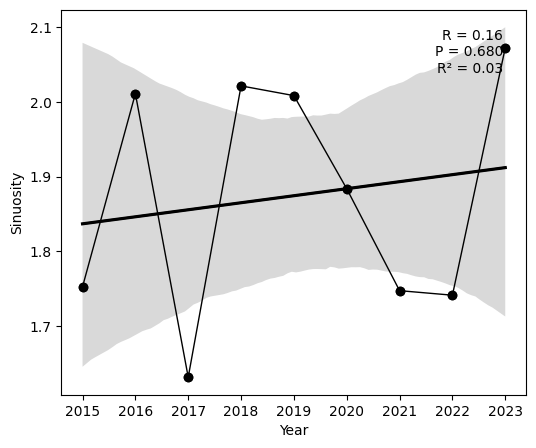

R: 0.1607435562075005
P: 0.679505166523609
R2: 0.025838490862233873


In [7]:
years = np.arange(2015, 2024)
x=years
y=res_sinuosity
#........................................................................................................   
fig, ax = plt.subplots(figsize=(6, 5))
# 计算线性回归
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
# 计算 R 方
r_squared = r_value ** 2
ax = sns.regplot(x=x, y=y, ci=95,color='black')
# 绘制散点图和回归线
plt.plot(x,y,'k-o', alpha=1, linewidth=1)
plt.plot(x, intercept + slope * np.array(x), 'black')
textstr = f"R = {r_value:.2f}\nP = {p_value:.3f}\nR² = {r_squared:.2f}"
ax.text(0.95, 0.95, textstr, transform=ax.transAxes,
        fontsize=10, va='top', ha='right')
plt.xlabel('Year')
plt.ylabel('Sinuosity')
plt.show()
print('R:',r_value)
print('P:', p_value)
print('R2:', r_squared)